# HW14 — эмбеддинги, FAISS, оценка retrieval и mini-RAG

Практическая работа 14 — Атаманчук А.В. КВБО-01-22

## 1. Импорты, seed и среда

In [1]:
import random
from pathlib import Path

import faiss
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
from IPython.display import display
from sentence_transformers import SentenceTransformer

print("sklearn", sklearn.__version__)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device (torch): {device}")

ARTIFACTS = Path("artifacts")
ARTIFACTS.mkdir(parents=True, exist_ok=True)


d:\VUZ\II_DOP_KURS\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


sklearn 1.8.0
Device (torch): cuda


## 2. База знаний и первичный анализ

База регламентов учебного курса (форматы работ, сроки, этика). Документы заданы в ноутбуке — воспроизводимо без внешних файлов.

Масштаб: 27 документов и три документа добавляются при обновлении (раздел 7); после чанкинга получается десятки текстовых фрагментов до обновления и ещё больше после.

Предметная область: внутренние правила курса — как сдавать работы, как оценивают, дедлайны, этика и ИИ-ассистенты, проект, окружение. Это связный набор нормативных текстов с фактами и формулировками, без художественного сюжета.

Почему здесь уместны retrieval и mini-RAG: студент задаёт вопрос своими словами («можно ли сдать через сутки?», «как оформить отчёт?»), а ответ должен опираться на конкретный абзац регламента, а не на общие знания модели. Векторный поиск по чанкам находит близкие по смыслу фрагменты; mini-RAG собирает из них контекст и возвращает ответ вместе с указанием источника — это как раз сценарий справочника / FAQ по корпусу документов.

In [2]:
KNOWLEDGE_DOCS = [
    {
        "doc_id": "doc_01",
        "title": "Цели курса и формат занятий",
        "text": "Курс «Прикладной искусственный интеллект» сочетает лекции и практические семинары. На лекциях даётся теоретическая база: модели машинного обучения, метрики качества, приёмы валидации и этика применения ИИ в приложениях. На семинарах разбираются ноутбуки с кодом: студенты выполняют упражнения и мини-проекты под руководством преподавателя, задают вопросы по реализации и интерпретации результатов. Посещение семинаров не отменяет необходимости самостоятельно просматривать записи лекций и материалы в LMS: часть контента публикуется только в виде слайдов и дополнительных ссылок. В конце каждого модуля проводится короткий опрос обратной связи для корректировки темпа курса.",
    },
    {
        "doc_id": "doc_02",
        "title": "Система оценивания",
        "text": "Итоговая оценка складывается из домашних работ, итогового проекта и устного зачёта. Домашние работы имеют вес около сорока процентов, проект — около тридцати пяти процентов, зачёт — около двадцати пяти процентов; точные доли фиксируются в LMS в начале семестра. Баллы за отдельные работы нормируются к шкале курса; допускается одна отсрочка по уважительной причине при письменном уведомлении до дедлайна. Итоговая оценка выставляется после защиты проекта и зачёта; при спорных случаях студент может запросить разбор критериев на консультации.",
    },
    {
        "doc_id": "doc_03",
        "title": "Дедлайны и штрафы",
        "text": "Дедлайн каждой работы указан в карточке задания в LMS и дублируется в календаре курса. Сдача в течение сорока восьми часов после дедлайна снижает балл не более чем на десять процентов от максимума за работу. Позднее работы без индивидуального согласования не принимаются, кроме случаев, оговорённых в регламенте академического отпуска. Контрольные точки проекта имеют отдельные жёсткие даты; пропуск точки без предупреждения влечёт снижение оценки за проект.",
    },
    {
        "doc_id": "doc_04",
        "title": "Оформление домашних работ",
        "text": "Каждая домашняя работа размещается в репозитории студента в каталоге homeworks/HWNN, где NN — номер работы с ведущим нулём при необходимости. Обязательны файлы, перечисленные в формулировке задания; имена файлов и каталогов регистрозависимы и должны совпадать с проверочными скриптами. Отчёт оформляется в Markdown по шаблону семинара без переименования разделов; в начале указываются ФИО, группа и номер работы. В репозитории не хранят большие веса моделей и датасеты: при необходимости даётся ссылка на облако или инструкция по загрузке.",
    },
    {
        "doc_id": "doc_05",
        "title": "Ноутбуки и воспроизводимость",
        "text": "Основной артефакт практических работ — Jupyter Notebook. Ноутбук должен выполняться последовательно Run All без ошибок в чистом окружении после установки зависимостей. Рекомендуется фиксировать seed для random, numpy и torch и указывать версии ключевых библиотек в первой ячейке или в requirements. Зависимости фиксируются в requirements.txt или в тексте отчёта; виртуальное окружение проекта нужно активировать перед запуском. Длинные обучения допускается прерывать с сохранением чекпоинта, но в ноутбуке должна быть ячейка, воспроизводящая финальную оценку на сохранённых весах.",
    },
    {
        "doc_id": "doc_06",
        "title": "Использование ИИ-ассистентов",
        "text": "Студенты могут использовать ИИ-инструменты как помощь в обучении и отладке, но обязаны понимать весь сдаваемый код и текст отчёта. Запрещено сдавать работу, в которой студент не может устно объяснить ключевые решения, источники данных и ограничения модели. При использовании чужих фрагментов кода или текста нужны явные ссылки на источник в комментариях или в отчёте; генерации ИИ помечаются как вспомогательный черновик, если это требует преподаватель.",
    },
    {
        "doc_id": "doc_07",
        "title": "Проект: постановка",
        "text": "Проект выполняется в конце семестра в группах по два-три человека; состав группы фиксируется в LMS до дедлайна регистрации. Тема согласуется до середины семестра; после согласования изменение темы возможно только по решению преподавателя. В поставке нужны постановка задачи, обзор литературы или аналогов, baseline, серия экспериментов и выводы с ограничениями и идеями улучшения. Код и краткая документация хранятся в отдельной ветке репозитория с тегом release; в README описывается запуск и структура каталогов.",
    },
    {
        "doc_id": "doc_08",
        "title": "Антиплагиат и этика",
        "text": "Работы проверяются на заимствования и на соответствие правилам цитирования и лицензий используемых данных. Копирование ноутбуков между студентами без указания соавторства и вклада каждого недопустимо и приравнивается к нарушению академической этики. Данные персонального характера в проектах использовать только с письменного согласия и планом обезличивания; публикация результатов в открытый доступ согласуется отдельно.",
    },
    {
        "doc_id": "doc_09",
        "title": "Консультации преподавателя",
        "text": "Очные консультации проходят по расписанию в аудитории, указанной в LMS; изменения переноса публикуются не позднее чем за сутки. На консультацию приносите конкретные вопросы, фрагменты кода и описание того, что уже пробовали; общие вопросы лучше задавать на семинаре. Преподаватель не решает задание целиком и не пишет код за студента, но может указать на ошибку в подходе или предложить направление поиска.",
    },
    {
        "doc_id": "doc_10",
        "title": "Технические требования к окружению",
        "text": "Рекомендуется Python версии три двенадцать или новее; для воспроизводимости указывайте минорную версию в отчёте. Для заданий с нейросетями желателен доступ к GPU, но допускается CPU при увеличении времени обучения и сокращении числа эпох в согласованных пределах. Библиотеки transformers, torch и datasets должны быть совместимы по версиям; при конфликтах приоритет у версий из официального примера курса. На Windows при проблемах с компиляцией расширений рекомендуется WSL2 или заранее согласованное облако.",
    },
    {
        "doc_id": "doc_11",
        "title": "Формат сдачи артефактов",
        "text": "Папка artifacts в каталоге работы содержит таблицы CSV, графики и вспомогательные файлы, перечисленные в формулировке задания. Не следует добавлять лишние бинарные файлы без необходимости; при необходимости больших файлов даётся внешняя ссылка с контрольной суммой. CSV сохраняют в кодировке UTF-8 с заголовком; разделитель — запятая, если в задании не указано иное. Имена колонок не переименовываются относительно шаблона проверки.",
    },
    {
        "doc_id": "doc_12",
        "title": "Пересдача",
        "text": "Пересдача зачёта возможна один раз в согласованный слот в конце семестра; запись на слот обязательна через LMS. Оценка за пересдачу не может быть выше удовлетворительно без отдельного решения комиссии и письменного обоснования. Домашние работы и этапы проекта пересдаются только при наличии уважительной причины и индивидуального плана, оформленного до дедлайна модуля.",
    },
    {
        "doc_id": "doc_13",
        "title": "Данные и датасеты для проекта",
        "text": "Выбор данных для итогового проекта согласуется с преподавателем и фиксируется в коротком документе постановки. Разрешены открытые датасеты из Kaggle, Hugging Face Datasets и официальных порталов статистики при явном указании лицензии и ссылки на версию. Запрещено использовать датасеты с персональными данными без плана обезличивания и согласия; самосбор данных описывается методикой и ограничениями выборки. Для воспроизводимости рекомендуется фиксировать хэш файла или номер ревизии датасета в README проекта.",
    },
    {
        "doc_id": "doc_14",
        "title": "Взаимная рецензия и разбор кода",
        "text": "На отдельных этапах проекта может проводиться взаимная рецензия: каждый студент получает один чужой отчёт по чек-листу ясности, воспроизводимости и корректности выводов. Рецензия сдаётся анонимно через форму в LMS; оскорбления и оценки без аргументации не допускаются. Преподаватель может засчитать рецензию как часть активности на семинаре; игнорирование рецензии без уважительной причины снижает балл за участие.",
    },
    {
        "doc_id": "doc_15",
        "title": "Перенос дедлайна: процедура",
        "text": "Перенос индивидуального дедлайна возможен не чаще одного раза на работу при письменной заявке в LMS до исходной даты сдачи. В заявке указываются причина, план догона и новая предлагаемая дата; преподаватель отвечает в течение трёх учебных дней. Массовые переносы по решению администрации объявляются отдельным объявлением и не требуют индивидуальных заявок.",
    },
    {
        "doc_id": "doc_16",
        "title": "Форум курса и правила общения",
        "text": "Технические вопросы по заданиям задаются в форуме курса в LMS с тегом номера работы; дублировать один и тот же вопрос в личные сообщения нежелательно. Запрещена публикация готовых решений или значимых фрагментов кода, снимающих учебную задачу; допускаются ссылки на документацию и общие советы по отладке. Нарушение правил ведёт к предупреждению или ограничению доступа к форуму на срок до конца модуля.",
    },
    {
        "doc_id": "doc_17",
        "title": "Онлайн-запись на консультацию",
        "text": "Для индивидуальных слотов используется календарь в LMS: студент выбирает окно длительностью до двадцати минут и получает ссылку на видеозвонок. Отмена записи возможна не позднее чем за двенадцать часов; неявка без отмены учитывается при ограничении будущих слотов при злоупотреблениях. Групповые разборы ошибок проводятся по расписанию семинара и не требуют отдельной записи.",
    },
    {
        "doc_id": "doc_18",
        "title": "README, лицензия и структура репозитория",
        "text": "В корне учебного репозитория рекомендуется README с описанием назначения веток, минимальными командами установки и ссылкой на курс. Если проект публикуется публично, указывается лицензия на код и отдельно — условия на данные, если они отличаются. Временные и служебные каталоги вроде .venv и кэшей добавляются в .gitignore; в репозиторий не коммитят секреты и токены доступа.",
    },
    {
        "doc_id": "doc_19",
        "title": "Устный зачёт: формат",
        "text": "Устный зачёт проходит очно или по видеосвязи в согласованные слоты; длительность одного студента — до пятнадцати минут. Студент отвечает на два-три вопроса по материалу семинаров и по содержанию сданных работ; допускается короткая шпаргалка формул на одной странице. Оценка выставляется сразу или в течение суток с комментарием в LMS; при неудовлетворительной оценке назначается пересдача по регламенту.",
    },
    {
        "doc_id": "doc_20",
        "title": "Совместная работа над домашними заданиями",
        "text": "Большинство домашних работ выполняется индивидуально; о совместной работе сказано явно в формулировке задания. Если разрешена пара, в отчёте указываются оба автора и вклад каждого в код и эксперименты; одинаковые отчёты без разделения вклада не принимаются. Обсуждение идей на общих форумах допускается, но реализация и отчёт должны быть самостоятельными, если не оговорено иное.",
    },
    {
        "doc_id": "doc_21",
        "title": "Резервные копии и работа с Git",
        "text": "Рекомендуется регулярно пушить изменения в удалённый репозиторий не реже одного раза в неделю во время активной фазы проекта. Ветки именуются по смыслу: main или master для стабильной версии, feature/* для экспериментов; перед тегом release выполняется слияние и проверка Run All. При потере локальных данных восстановление возможно из удалённого репозитория; комиссия не принимает потерю ноутбука как основание для бессрочного переноса без заявки.",
    },
    {
        "doc_id": "doc_22",
        "title": "Конфиденциальность и публикация результатов",
        "text": "Промежуточные оценки и переписка с преподавателем не публикуются без согласия. Итоговые проекты могут выставляться в портфолио при условии отсутствия закрытых данных и согласия всех участников группы. При использовании корпоративных или партнёрских данных действует отдельное соглашение о неразглашении, которое студент подписывает до начала работы.",
    },
    {
        "doc_id": "doc_23",
        "title": "Бонусные баллы и внеаудиторная активность",
        "text": "За участие в студенческих мероприятиях курса, докладах на семинарах и помощи в модерации форума начисляются бонусные баллы в пределах пяти процентов от модуля домашних работ. Бонусы фиксируются преподавателем в LMS до пересчёта итоговой оценки; перенос бонусов на следующий семестр не производится. Нарушение правил этики при модерации или плагиат в докладе обнуляет бонусы за весь семестр.",
    },
    {
        "doc_id": "doc_24",
        "title": "Гостевые лекции и учёт посещаемости",
        "text": "Гостевые лекции анонсируются заранее в LMS; посещение по желанию, но рекомендуется для тем, выходящих за рамки базовой программы. На гостевых лекциях не проводится отметка посещаемости, если это не оговорено отдельно как часть зачёта. Записи гостевых выступлений выкладываются при согласии спикера и могут быть доступны ограниченное время.",
    },
    {
        "doc_id": "doc_25",
        "title": "Облачные GPU-кредиты учебного курса",
        "text": "Курс может предоставлять ограниченные кредиты на облачные GPU для студентов без локальной карты; распределение по заявкам в форме LMS. Кредиты не продлеваются автоматически; по исчерпании лимита студент переходит на CPU или собственное облако. Запрещено передавать учётные данные третьим лицам и майнить вне учебных заданий под учётной записью курса.",
    },
    {
        "doc_id": "doc_26",
        "title": "API-ключи, секреты и переменные окружения",
        "text": "Ключи внешних API и токены доступа хранят только в переменных окружения или в локальном файле .env, исключённом из Git. В ноутбуках и отчётах не публикуются реальные значения секретов; для примеров используются плейсхолдеры. Утечка ключа из репозитория студента влечёт пересоздание ключа и может повлиять на оценку за нарушение безопасности.",
    },
    {
        "doc_id": "doc_27",
        "title": "Промежуточная сдача проекта (middle checkpoint)",
        "text": "К середине семестра команды сдают короткий отчёт о постановке, собранных данных и первом baseline без финальной оптимизации. Формат — Markdown в ветке проекта и короткая презентация на семинаре до пятнадцати минут. За пропуск middle checkpoint без согласования снимается до десяти процентов от максимума за проект.",
    },
]

docs_df = pd.DataFrame(KNOWLEDGE_DOCS)
print("Число документов:", len(KNOWLEDGE_DOCS))
display(docs_df[["doc_id", "title"]])
print("\nПримеры фрагментов текста:\n")
for row in KNOWLEDGE_DOCS[:4]:
    snippet = row["text"][:220] + ("…" if len(row["text"]) > 220 else "")
    print(f"[{row['doc_id']}] {row['title']}: {snippet}\n")


Число документов: 27


,doc_id,title
0,doc_01,Цели курса и формат занятий
1,doc_02,Система оценивания
2,doc_03,Дедлайны и штрафы
3,doc_04,Оформление домашних работ
4,doc_05,Ноутбуки и воспроизводимость
5,doc_06,Использование ИИ-ассистентов
6,doc_07,Проект: постановка
7,doc_08,Антиплагиат и этика
8,doc_09,Консультации преподавателя
9,doc_10,Технические требования к окружению



Примеры фрагментов текста:

[doc_01] Цели курса и формат занятий: Курс «Прикладной искусственный интеллект» сочетает лекции и практические семинары. На лекциях даётся теоретическая база: модели машинного обучения, метрики качества, приёмы валидации и этика применения ИИ в приложениях. …

[doc_02] Система оценивания: Итоговая оценка складывается из домашних работ, итогового проекта и устного зачёта. Домашние работы имеют вес около сорока процентов, проект — около тридцати пяти процентов, зачёт — около двадцати пяти процентов; точные …

[doc_03] Дедлайны и штрафы: Дедлайн каждой работы указан в карточке задания в LMS и дублируется в календаре курса. Сдача в течение сорока восьми часов после дедлайна снижает балл не более чем на десять процентов от максимума за работу. Позднее рабо…

[doc_04] Оформление домашних работ: Каждая домашняя работа размещается в репозитории студента в каталоге homeworks/HWNN, где NN — номер работы с ведущим нулём при необходимости. Обязательны файлы, перечислен

## 3. Чанкинг документов

Разбиение по символам с перекрытием (overlap). По умолчанию: `chunk_size=320`, `overlap=55`.


In [3]:
def chunk_text(text: str, chunk_size: int = 320, overlap: int = 55) -> list[str]:
    if chunk_size <= 0:
        raise ValueError("chunk_size must be positive")
    overlap = min(max(overlap, 0), chunk_size - 1) if chunk_size > 1 else 0
    chunks = []
    start = 0
    n = len(text)
    while start < n:
        end = min(start + chunk_size, n)
        chunks.append(text[start:end])
        if end == n:
            break
        start = max(end - overlap, start + 1)
    return chunks


def build_chunk_records(docs: list[dict], chunk_size: int, overlap: int) -> list[dict]:
    records = []
    for doc in docs:
        parts = chunk_text(doc["text"], chunk_size=chunk_size, overlap=overlap)
        for j, part in enumerate(parts):
            records.append(
                {
                    "doc_id": doc["doc_id"],
                    "title": doc["title"],
                    "chunk_idx": j,
                    "chunk_uid": f"{doc['doc_id']}#{j}",
                    "text": part,
                }
            )
    return records


CHUNK_SIZE = 320
OVERLAP = 55
chunks = build_chunk_records(KNOWLEDGE_DOCS, CHUNK_SIZE, OVERLAP)
print(f"Всего чанков: {len(chunks)} (chunk_size={CHUNK_SIZE}, overlap={OVERLAP})")

example_doc = KNOWLEDGE_DOCS[4]
raw_chunks = chunk_text(example_doc["text"], CHUNK_SIZE, OVERLAP)
print(f"\nДокумент {example_doc['doc_id']} — {example_doc['title']}")
print("Полный текст:", example_doc["text"])
print("\nЧанки:")
for i, c in enumerate(raw_chunks):
    print(f"--- chunk {i} ({len(c)} симв.) ---\n{c}\n")


Всего чанков: 54 (chunk_size=320, overlap=55)

Документ doc_05 — Ноутбуки и воспроизводимость
Полный текст: Основной артефакт практических работ — Jupyter Notebook. Ноутбук должен выполняться последовательно Run All без ошибок в чистом окружении после установки зависимостей. Рекомендуется фиксировать seed для random, numpy и torch и указывать версии ключевых библиотек в первой ячейке или в requirements. Зависимости фиксируются в requirements.txt или в тексте отчёта; виртуальное окружение проекта нужно активировать перед запуском. Длинные обучения допускается прерывать с сохранением чекпоинта, но в ноутбуке должна быть ячейка, воспроизводящая финальную оценку на сохранённых весах.

Чанки:
--- chunk 0 (320 симв.) ---
Основной артефакт практических работ — Jupyter Notebook. Ноутбук должен выполняться последовательно Run All без ошибок в чистом окружении после установки зависимостей. Рекомендуется фиксировать seed для random, numpy и torch и указывать версии ключевых библиотек в первой яче

## 4. Эмбеддинги и индекс FAISS

Модель: **sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2**. Векторы L2-нормируются; индекс **FAISS IndexFlatIP** (косинусная близость для нормированных эмбеддингов).


In [4]:
EMB_MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
embedder = SentenceTransformer(EMB_MODEL_NAME, device=str(device))

texts = [c["text"] for c in chunks]
emb = embedder.encode(texts, batch_size=32, show_progress_bar=True, normalize_embeddings=True)
emb = np.asarray(emb, dtype=np.float32)
dim = emb.shape[1]

index = faiss.IndexFlatIP(dim)
index.add(emb)
print(f"Индекс: ntotal={index.ntotal}, dim={dim}")


def search_index(query: str, top_k: int = 5):
    qv = embedder.encode([query], normalize_embeddings=True).astype(np.float32)
    scores, idx = index.search(qv, top_k)
    hits = []
    for rank, (i, s) in enumerate(zip(idx[0], scores[0])):
        if i < 0:
            continue
        rec = dict(chunks[i])
        rec["score"] = float(s)
        rec["rank"] = rank + 1
        hits.append(rec)
    return hits


demo_queries = [
    "Как оформить домашнюю работу в репозитории?",
    "Что входит в итоговую оценку?",
    "Можно ли опоздать со сдачей на сутки?",
    "Какие правила использования ИИ на курсе?",
]

for dq in demo_queries:
    print(f"\n=== Запрос: {dq} ===")
    for h in search_index(dq, top_k=3):
        print(f"  rank {h['rank']} | {h['doc_id']} | score={h['score']:.4f}")
        print(f"    {h['text'][:160]}…")


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5997.72it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 2/2 [00:06<00:00,  3.19s/it]


Индекс: ntotal=54, dim=384

=== Запрос: Как оформить домашнюю работу в репозитории? ===
  rank 1 | doc_20 | score=0.6199
    Большинство домашних работ выполняется индивидуально; о совместной работе сказано явно в формулировке задания. Если разрешена пара, в отчёте указываются оба авт…
  rank 2 | doc_04 | score=0.6111
    Каждая домашняя работа размещается в репозитории студента в каталоге homeworks/HWNN, где NN — номер работы с ведущим нулём при необходимости. Обязательны файлы,…
  rank 3 | doc_07 | score=0.5971
    Проект выполняется в конце семестра в группах по два-три человека; состав группы фиксируется в LMS до дедлайна регистрации. Тема согласуется до середины семестр…

=== Запрос: Что входит в итоговую оценку? ===
  rank 1 | doc_02 | score=0.6182
    Итоговая оценка складывается из домашних работ, итогового проекта и устного зачёта. Домашние работы имеют вес около сорока процентов, проект — около тридцати пя…
  rank 2 | doc_02 | score=0.5903
    лы за отдельные работы нормируют

## 5. Контрольные запросы и оценка retrieval

**10** запросов, для каждого указан ожидаемый документ.

- **hit@k**: среди top-k чанков есть хотя бы один чанк из ожидаемого документа.
- **recall@k**: |релевантные чанки ∩ top-k| / |все чанки ожидаемого документа|, усреднение по запросам.


In [5]:
CONTROL_QUERIES = [
    {"query": "Где лежит папка с домашкой и как назвать отчёт?", "expected_doc": "doc_04"},
    {"query": "Сколько процентов даёт проект в оценке?", "expected_doc": "doc_02"},
    {"query": "Что будет если сдать работу через сутки после дедлайна?", "expected_doc": "doc_03"},
    {"query": "Нужно ли фиксировать seed в ноутбуке?", "expected_doc": "doc_05"},
    {"query": "Обязан ли студент понимать код, если он пользовался ChatGPT?", "expected_doc": "doc_06"},
    {"query": "В каком составе делается итоговый проект?", "expected_doc": "doc_07"},
    {"query": "Можно ли копировать ноутбук у одногруппника без указания соавторов?", "expected_doc": "doc_08"},
    {"query": "Какая версия Python рекомендуется?", "expected_doc": "doc_10"},
    {"query": "В какой кодировке сохранять CSV в artifacts?", "expected_doc": "doc_11"},
    {"query": "Сколько раз можно пересдать зачёт?", "expected_doc": "doc_12"},
]

K_EVAL = 5


def evaluate_on_chunks(chunk_list: list[dict], top_k: int):
    texts_loc = [c["text"] for c in chunk_list]
    mat = embedder.encode(
        texts_loc, batch_size=32, show_progress_bar=False, normalize_embeddings=True
    ).astype(np.float32)
    loc_index = faiss.IndexFlatIP(mat.shape[1])
    loc_index.add(mat)

    rows = []
    hits = []
    recalls = []

    for item in CONTROL_QUERIES:
        q = item["query"]
        exp = item["expected_doc"]
        rel = {i for i, c in enumerate(chunk_list) if c["doc_id"] == exp}

        qv = embedder.encode([q], normalize_embeddings=True).astype(np.float32)
        _, idx = loc_index.search(qv, top_k)
        retrieved_idx = [int(i) for i in idx[0] if i >= 0]

        rel_found = [i for i in retrieved_idx if i in rel]
        hit = int(len(rel_found) > 0)
        hits.append(hit)
        rec = 0.0 if len(rel) == 0 else len(set(retrieved_idx) & rel) / len(rel)
        recalls.append(rec)

        retrieved_sources = [chunk_list[ci]["doc_id"] for ci in retrieved_idx]

        rank_first = None
        for rank, ci in enumerate(retrieved_idx, start=1):
            if ci in rel:
                rank_first = rank
                break

        rows.append(
            {
                "query": q,
                "expected_source": exp,
                "retrieved_sources": ";".join(retrieved_sources),
                "hit_at_k": hit,
                "rank_of_first_relevant": rank_first if rank_first is not None else "",
                "recall_at_k": rec,
            }
        )

    df_eval = pd.DataFrame(rows)
    return df_eval, float(np.mean(hits)), float(np.mean(recalls))


df_eval, hit_k, recall_k = evaluate_on_chunks(chunks, K_EVAL)
print(f"hit@{K_EVAL} (среднее по запросам): {hit_k:.4f}")
print(f"recall@{K_EVAL} (среднее по запросам): {recall_k:.4f}")
display(df_eval)


hit@5 (среднее по запросам): 1.0000
recall@5 (среднее по запросам): 0.7500


,query,expected_source,retrieved_sources,hit_at_k,rank_of_first_relevant,recall_at_k
0,Где лежит папка с домашкой и как назвать отчёт?,doc_04,doc_07;doc_04;doc_04;doc_25;doc_02,1,2,1.0
1,Сколько процентов даёт проект в оценке?,doc_02,doc_02;doc_02;doc_23;doc_27;doc_22,1,1,1.0
2,Что будет если сдать работу через сутки после ...,doc_03,doc_03;doc_15;doc_27;doc_02;doc_03,1,1,1.0
3,Нужно ли фиксировать seed в ноутбуке?,doc_05,doc_05;doc_05;doc_21;doc_08;doc_10,1,1,1.0
4,"Обязан ли студент понимать код, если он пользо...",doc_06,doc_09;doc_06;doc_18;doc_26;doc_09,1,2,0.5
5,В каком составе делается итоговый проект?,doc_07,doc_07;doc_22;doc_02;doc_27;doc_05,1,1,0.5
6,Можно ли копировать ноутбук у одногруппника бе...,doc_08,doc_08;doc_21;doc_22;doc_20;doc_05,1,1,0.5
7,Какая версия Python рекомендуется?,doc_10,doc_10;doc_21;doc_18;doc_02;doc_01,1,1,0.5
8,В какой кодировке сохранять CSV в artifacts?,doc_11,doc_11;doc_11;doc_18;doc_13;doc_18,1,1,1.0
9,Сколько раз можно пересдать зачёт?,doc_12,doc_19;doc_15;doc_12;doc_02;doc_03,1,3,0.5


## 6. Эксперимент: два значения `chunk_size`

Сравниваем **chunk_size=220** и **chunk_size=480** при фиксированном `overlap=55`. Метрики — те же hit@k и recall@k на контрольных запросах, `k=5`.


,chunk_size,num_chunks,hit@5,recall@5
0,220,73,1.0,0.616667
1,480,34,1.0,0.800000


Вывод: мелкие чанки дают больше фрагментов и иногда лучше попадают в точную формулировку; крупные — сохраняют больше контекста в одном векторе. Для основного прогона выбран компромисс chunk_size=320.


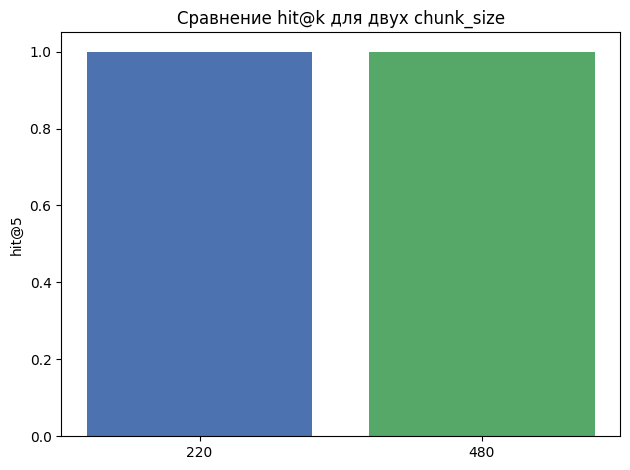

In [6]:
SIZE_A, SIZE_B = 220, 480
chunks_a = build_chunk_records(KNOWLEDGE_DOCS, SIZE_A, OVERLAP)
chunks_b = build_chunk_records(KNOWLEDGE_DOCS, SIZE_B, OVERLAP)

_, hit_a, rec_a = evaluate_on_chunks(chunks_a, K_EVAL)
_, hit_b, rec_b = evaluate_on_chunks(chunks_b, K_EVAL)

exp_df = pd.DataFrame(
    [
        {"chunk_size": SIZE_A, "num_chunks": len(chunks_a), f"hit@{K_EVAL}": hit_a, f"recall@{K_EVAL}": rec_a},
        {"chunk_size": SIZE_B, "num_chunks": len(chunks_b), f"hit@{K_EVAL}": hit_b, f"recall@{K_EVAL}": rec_b},
    ]
)
display(exp_df)

print(
    "Вывод: мелкие чанки дают больше фрагментов и иногда лучше попадают в точную формулировку; "
    "крупные — сохраняют больше контекста в одном векторе. Для основного прогона выбран компромисс chunk_size=320."
)

fig, ax = plt.subplots()
ax.bar([str(SIZE_A), str(SIZE_B)], [hit_a, hit_b], color=["#4C72B0", "#55A868"])
ax.set_ylabel(f"hit@{K_EVAL}")
ax.set_title("Сравнение hit@k для двух chunk_size")
plt.tight_layout()
plt.show()


## 7. Обновление базы знаний и переиндексация

Добавляем **3** новых документа (`doc_28`–`doc_30`: записи вебинаров, каталог примеров, академический отпуск). Затем заново чанкинг и FAISS. Сравниваем top-5 до и после для запросов, затрагивающих новые темы.


In [7]:
NEW_DOCS = [
    {
        "doc_id": "doc_28",
        "title": "Записи онлайн-вебинаров",
        "text": "Записи онлайн-вебинаров выкладываются в раздел LMS «Видео» в течение суток после эфира. Файлы названы по дате и теме. Для доступа нужна учётная запись студента. Ссылки на внешние стриминговые сервисы без пароля курса не используются.",
    },
    {
        "doc_id": "doc_29",
        "title": "Каталог примеров кода",
        "text": "В репозитории курса есть каталог examples с эталонными фрагментами. Их можно копировать с явной ссылкой на файл-источник в комментарии и в отчёте. Запрещено выдавать чужие решения домашних работ за свои даже с изменением имён переменных.",
    },
    {
        "doc_id": "doc_30",
        "title": "Академический отпуск",
        "text": "При оформленном академическом отпуске дедлайны переносятся по индивидуальному плану, согласованному с куратором. Студент письменно уведомляет преподавателя до выхода на отпуск. После возвращения даётся до четырёх недель на догоняние пропущенных работ без штрафа.",
    },
]

chunks_before = list(chunks)
emb_before = emb.copy()
index_before = faiss.IndexFlatIP(emb_before.shape[1])
index_before.add(emb_before)

KNOWLEDGE_EXTENDED = KNOWLEDGE_DOCS + NEW_DOCS
chunks_after = build_chunk_records(KNOWLEDGE_EXTENDED, CHUNK_SIZE, OVERLAP)
texts_after = [c["text"] for c in chunks_after]
emb_after = embedder.encode(
    texts_after, batch_size=32, show_progress_bar=True, normalize_embeddings=True
).astype(np.float32)
index_after = faiss.IndexFlatIP(emb_after.shape[1])
index_after.add(emb_after)

print(f"Чанков до обновления: {len(chunks_before)}, после: {len(chunks_after)}")

compare_queries = [
    "Где лежат записи онлайн-вебинаров после эфира?",
    "Можно ли брать код из каталога examples и как его цитировать?",
    "Что делать с дедлайнами при академическом отпуске?",
    "Сколько недель даётся на догон пропущенных работ после академического отпуска?",
]

before_after_rows = []
for cq in compare_queries:
    qv = embedder.encode([cq], normalize_embeddings=True).astype(np.float32)
    _, ib = index_before.search(qv, 5)
    before_src = ";".join(chunks_before[int(i)]["doc_id"] for i in ib[0] if i >= 0)
    _, ia = index_after.search(qv, 5)
    after_src = ";".join(chunks_after[int(i)]["doc_id"] for i in ia[0] if i >= 0)
    before_after_rows.append(
        {
            "query": cq,
            "before_retrieved_sources": before_src,
            "after_retrieved_sources": after_src,
            "changed": int(before_src != after_src),
        }
    )

df_before_after = pd.DataFrame(before_after_rows)
display(df_before_after)


chunks = chunks_after
index = index_after
emb = emb_after


Batches: 100%|██████████| 2/2 [00:00<00:00,  9.20it/s]

Чанков до обновления: 54, после: 57


,query,before_retrieved_sources,after_retrieved_sources,changed
0,Где лежат записи онлайн-вебинаров после эфира?,doc_24;doc_19;doc_24;doc_16;doc_09,doc_28;doc_24;doc_19;doc_24;doc_16,1
1,Можно ли брать код из каталога examples и как ...,doc_07;doc_18;doc_06;doc_11;doc_04,doc_07;doc_29;doc_18;doc_06;doc_11,1
2,Что делать с дедлайнами при академическом отпу...,doc_19;doc_03;doc_07;doc_23;doc_03,doc_30;doc_19;doc_03;doc_07;doc_23,1
3,Сколько недель даётся на догон пропущенных раб...,doc_19;doc_27;doc_03;doc_03;doc_07,doc_30;doc_19;doc_27;doc_03;doc_03,1


## 8. Mini-RAG

Пайплайн: запрос → top-k чанков → контекст → **экстрактивный** ответ (первый релевантный фрагмент, усечённый) + список уникальных `doc_id`. Это учебная заглушка вместо тяжёлой LLM.


In [8]:
def mini_rag(question: str, top_k: int = 4) -> tuple[str, list[str], list[dict]]:
    hits = search_index(question, top_k=top_k)
    if not hits:
        return "Контекст не найден.", [], []
    context_blocks = []
    for h in hits:
        context_blocks.append(f"[{h['doc_id']}] {h['text']}")
    context = "\n\n".join(context_blocks)
    best = hits[0]["text"].strip()
    if len(best) > 450:
        best = best[:450] + "…"
    answer = (
        "Кратко по найденным фрагментам: "
        + best
        + " (см. источники в поле retrieved_sources)."
    )
    sources = list(dict.fromkeys(h["doc_id"] for h in hits))
    return answer, sources, hits


rag_demo_questions = [
    "Как оформить домашнюю работу в репозитории?",
    "Какой вес у домашних заданий в оценке?",
    "Где смотреть записи вебинаров?",
    "Что с дедлайнами при академическом отпуске?",
    "Нужен ли GPU для заданий с нейросетями?",
]

rag_rows = []
for rq in rag_demo_questions:
    ans, src, _hits = mini_rag(rq, top_k=4)
    print(f"\nQ: {rq}\nA: {ans}\nИсточники: {src}\n")
    rag_rows.append(
        {"question": rq, "answer": ans, "retrieved_sources": ";".join(src)}
    )

df_rag = pd.DataFrame(rag_rows)
display(df_rag)



Q: Как оформить домашнюю работу в репозитории?
A: Кратко по найденным фрагментам: Большинство домашних работ выполняется индивидуально; о совместной работе сказано явно в формулировке задания. Если разрешена пара, в отчёте указываются оба автора и вклад каждого в код и эксперименты; одинаковые отчёты без разделения вклада не принимаются. Обсуждение идей на общих форумах допускается, но реализация и (см. источники в поле retrieved_sources).
Источники: ['doc_20', 'doc_04', 'doc_07']


Q: Какой вес у домашних заданий в оценке?
A: Кратко по найденным фрагментам: Итоговая оценка складывается из домашних работ, итогового проекта и устного зачёта. Домашние работы имеют вес около сорока процентов, проект — около тридцати пяти процентов, зачёт — около двадцати пяти процентов; точные доли фиксируются в LMS в начале семестра. Баллы за отдельные работы нормируются к шкале курса; допус (см. источники в поле retrieved_sources).
Источники: ['doc_02', 'doc_04', 'doc_23']


Q: Где смотреть записи веби

,question,answer,retrieved_sources
0,Как оформить домашнюю работу в репозитории?,Кратко по найденным фрагментам: Большинство до...,doc_20;doc_04;doc_07
1,Какой вес у домашних заданий в оценке?,Кратко по найденным фрагментам: Итоговая оценк...,doc_02;doc_04;doc_23
2,Где смотреть записи вебинаров?,Кратко по найденным фрагментам: Записи онлайн-...,doc_28;doc_01;doc_18;doc_07
3,Что с дедлайнами при академическом отпуске?,Кратко по найденным фрагментам: При оформленно...,doc_30;doc_19;doc_23;doc_03
4,Нужен ли GPU для заданий с нейросетями?,Кратко по найденным фрагментам: Рекомендуется ...,doc_10;doc_25;doc_05;doc_21


## 9. Краткий анализ ошибок и ограничений

Ниже — типичные **пограничные** случаи mini-RAG при простом эстрактивном ответе. Для каждого запроса вызывается тот же `mini_rag`, что в разделе 8: сначала печатаются ответ и источники, затем краткий комментарий (что пошло не так: retrieval, контекст, формулировка вопроса или полнота базы).


In [9]:
error_cases = [
    (
        "Сколько именно процентов у зачёта?",
        "Модель может вернуть чанк про веса, но эстрактивный ответ берёт начало фрагмента; точные числа иногда «глубже» в абзаце.",
    ),
    (
        "Можно ли не ходить на лекции?",
        "Формулировка близка к нескольким документам; retrieval может смешать doc_01 и doc_09, ответ станет менее фокусным.",
    ),
    (
        "Как оформить командировку на выездную защиту проекта за границей?",
        "Такой процедуры в учебной базе нет — retrieval вернёт общие документы о проекте и зачёте, возможны ложные релевантные фрагменты.",
    ),
    (
        "Как оформить отчёт если шаблон изменился?",
        "Если информации нет в базе, top-k всё равно вернёт что-то похожее по токенам — возможны ложные источники.",
    ),
]

print("=== Пограничные запросы: фактический вывод mini-RAG (тот же конвейер, что в разделе 8) ===\n")
for q, comment in error_cases:
    ans, src, _hits = mini_rag(q, top_k=4)
    print(f"Запрос: {q}")
    print(f"Ответ: {ans[:380]}{'…' if len(ans) > 380 else ''}")
    print(f"Источники (doc_id): {';'.join(src)}")
    print(f"Комментарий: {comment}\n")

print(
    "Итого: качество mini-RAG здесь ограничено retrieval, полнотой базы и тем, "
    "что генератор не перефразирует, а копирует фрагмент."
)


=== Пограничные запросы: фактический вывод mini-RAG (тот же конвейер, что в разделе 8) ===

Запрос: Сколько именно процентов у зачёта?
Ответ: Кратко по найденным фрагментам: Итоговая оценка складывается из домашних работ, итогового проекта и устного зачёта. Домашние работы имеют вес около сорока процентов, проект — около тридцати пяти процентов, зачёт — около двадцати пяти процентов; точные доли фиксируются в LMS в начале семестра. Баллы за отдельные работы нормируются к шкале курса; допус (см. источники в поле retri…
Источники (doc_id): doc_02;doc_25;doc_19
Комментарий: Модель может вернуть чанк про веса, но эстрактивный ответ берёт начало фрагмента; точные числа иногда «глубже» в абзаце.

Запрос: Можно ли не ходить на лекции?
Ответ: Кратко по найденным фрагментам: Гостевые лекции анонсируются заранее в LMS; посещение по желанию, но рекомендуется для тем, выходящих за рамки базовой программы. На гостевых лекциях не проводится отметка посещаемости, если это не оговорено отдельно как ча

## 10. Сохранение артефактов (CSV)


In [10]:
# Основная оценка на базовой базе (до расширения)
df_eval.to_csv(ARTIFACTS / "retrieval_eval.csv", index=False, encoding="utf-8")
df_rag.to_csv(ARTIFACTS / "rag_examples.csv", index=False, encoding="utf-8")
df_before_after.to_csv(ARTIFACTS / "retrieval_before_after_update.csv", index=False, encoding="utf-8")

print("Сохранено:", ARTIFACTS / "retrieval_eval.csv")
print("Сохранено:", ARTIFACTS / "rag_examples.csv")
print("Сохранено:", ARTIFACTS / "retrieval_before_after_update.csv")


Сохранено: artifacts\retrieval_eval.csv
Сохранено: artifacts\rag_examples.csv
Сохранено: artifacts\retrieval_before_after_update.csv
